In [ ]:
import numpy as np

class MCMC:
    def __init__(self, target_log_prob, inital_state, proposal_ss=1):
        self.target_log_prob = target_log_prob
        self.current_state = inital_state
        self.propsal_ss = proposal_ss
        self.chain = []
        self.accepted = 0
        self.proposed = 0
        self.accepted_methods = ['metropolis', 'hmc']
    
    def proposal_step(self):
        return np.random.uniform(self.current_state - self.proposal_ss, self.current_state + self.proposal_ss)
    
    def _metropolis(self, n_samples=1000, burn_in=1000):
        """metropolis algorithm"""
         
        for i in range(num_samples + burn_in):
            proposed_state = self.proposal_step()
            
            # Log-acceptance ratio
            log_p_curr = self.target_log_prob(self.current_state)
            log_p_prop = self.target_log_prob(proposed_state)
            
            # Accept/Reject
            if np.log(np.random.rand()) < (log_p_prop - log_p_curr):
                self.current_state = proposed_state
                if i >= burn_in: self.accepted += 1
            
            if i >= burn_in:
                self.chain.append(self.current_state)
                self.proposed += 1
                
        print(f'Total proposed = {self.proposed}')
        print(f'Total accepted = {self.accepted}')
        print(f'Acceptance ratio = {self.accepted/self.proposed:.2f}')
            
                
        return np.array(self.chain)
                
            
    
    def sample(self, method='metropolis', **kwargs):
        try: 
            method in self.accepted_methods
        except:
            raise Exception(f"Method must be in {accepted_methods}")
        
        return _metropolis(self, **kwargs)
            
            
            
        
        
        
        

In [ ]:
import numpy as np

class MCMC:
    def __init__(self, target_log_prob, initial_state, proposal_std=1):
        self.target_log_prob = target_log_prob
        self.current_state = initial_state
        self.proposal_std = proposal_std
        self.chain = []
        self.accepted = 0
        self.proposed = 0
        self.accepted_methods = ['metropolis', 'hmc']
    
    def proposal_step(self):
           return np.random.normal(self.current_state, self.proposal_std)
    
    def _metropolis(self, n_samples=1000, burn_in=1000):
        """metropolis algorithm"""
         
        for i in range(n_samples + burn_in):
            proposed_state = self.proposal_step()
            
            # Log-acceptance ratio
            log_p_curr = self.target_log_prob(self.current_state)
            log_p_prop = self.target_log_prob(proposed_state)
            
            # Accept/Reject
            if np.log(np.random.rand()) < (log_p_prop - log_p_curr):
                self.current_state = proposed_state
                if i >= burn_in: self.accepted += 1
            
            if i >= burn_in:
                self.chain.append(self.current_state)
                self.proposed += 1
                            
        return np.array(self.chain)
                
                
    def _hmc(self, n_samples=1000, burn_in=1000):
        pass
            
    
    def sample(self, method='metropolis', **kwargs):

        match method:
            case 'metropolis':
                samples = self._metropolis(**kwargs)
            
            case 'hmc':
                samples = self._hmc(**kwargs)
                
            case _ :
                raise Exception(f"Method must be in {self.accepted_methods}")
        
        print(f'Total proposed = {self.proposed}')
        print(f'Total accepted = {self.accepted}')
        print(f'Acceptance ratio = {self.accepted/self.proposed:.2f}')
        return samples
            
            
            

In [ ]:
target = lambda x: -0.5 * x**2 
sampler = MCMC(target, initial_state=0.0)

In [56]:
samples = sampler.sample(method = 'metropoli', n_samples = 10000)

Exception: Method must be in ['metropolis', 'hmc']

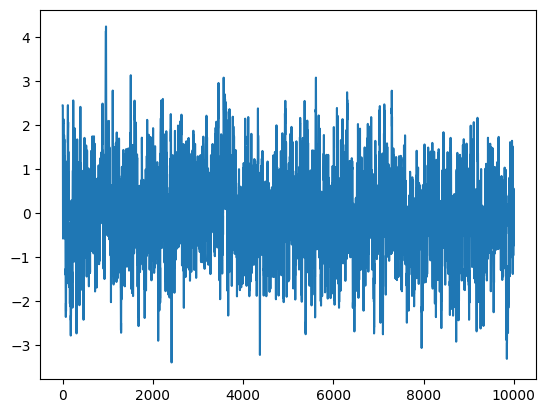

In [48]:
import matplotlib.pyplot as plt
plt.plot(samples)

In [50]:
np.average(samples)
#np.std(samples)
#np.quantile(samples, q = 0.33)

np.float64(-0.043825817083790186)

In [57]:
import numpy as np
from dataclasses import dataclass
from typing import Callable
import warnings

@dataclass
class MCMCResult:
    samples: np.ndarray
    acceptance_rate: float
    method: str

    def __repr__(self):
        return (f"MCMCResult(method={self.method}, "
                f"n_samples={len(self.samples)}, "
                f"acceptance_rate={self.acceptance_rate:.3f})")


class MCMC:
    def __init__(self, target_log_prob: Callable, initial_state: float, proposal_std: float = 1.0):
        self.target_log_prob = target_log_prob
        self.initial_state = initial_state
        self.proposal_std = proposal_std

    def _metropolis(self, n_samples: int, burn_in: int) -> MCMCResult:
        state = self.initial_state
        chain = []
        accepted = 0

        for i in range(n_samples + burn_in):
            proposed = np.random.normal(state, self.proposal_std)

            log_alpha = self.target_log_prob(proposed) - self.target_log_prob(state)

            if np.log(np.random.rand()) < log_alpha:
                state = proposed
                if i >= burn_in:
                    accepted += 1

            if i >= burn_in:
                chain.append(state)

        return MCMCResult(
            samples=np.array(chain),
            acceptance_rate=accepted / n_samples,
            method='metropolis'
        )


    

    def sample(self, method: str = 'metropolis', n_samples: int = 1000,
               burn_in: int = 1000, **kwargs) -> MCMCResult:

        match method:
            case 'metropolis':
                result = self._metropolis(n_samples, burn_in)
            case 'hmc':
                hmc_kwargs = {'step_size': 0.1, 'n_leapfrog': 20} | kwargs
                result = self._hmc(n_samples, burn_in, **hmc_kwargs)
            case _:
                raise ValueError(f"Unknown method '{method}'. Choose from: metropolis, hmc")

        print(result)
        return result

In [10]:
import scipy.stats as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


class Normal:
    
    def __init__(self, mean, std):
        self.mean = mean        
        self.std = std
        
    def log_prob(self, x):
        return sp.norm.logpdf(x, self.mean, self.std)
    
class Uniform:
    
    def __init__(self, low, high):
        self.low = low
        self.high = high
        
    def log_prob(self, x):
        return sp.uniform.logpdf(x, self.low, self.high - self.low)

class Exponential:
    
    def __init__(self, rate):
        self.rate = rate
        
    def log_prob(self, x):
        return sp.expon.logpdf(x, scale=1/self.rate)
    
class Bernoulli:
    
    def __init__(self, p):
        self.p = p
        
    def log_prob(self, x):
        return sp.bernoulli.logpmf(x, self.p)   
    
class Beta:
    
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        
    def log_prob(self, x):
        return sp.beta.logpdf(x, self.alpha, self.beta)

class Poisson: 
    
    def __init__(self, lam):
        self.lam = lam
        
    def log_prob(self, x):
        return sp.poisson.logpmf(x, self.lam)

class HalfNormal:
    
    def __init__(self, scale):
        self.scale = scale
        
    def log_prob(self, x):
        return sp.halfnorm.logpdf(x, scale=self.scale)


True alpha: 1.0, True beta: 2.5, True sigma: 1.0
N = 50

Total proposed    = 4000
Total accepted    = 470
Acceptance ratio  = 0.12

Posterior means:
  alpha = 1.043  (true: 1.0)
  beta  = 2.616  (true: 2.5)
  sigma = 0.898  (true: 1.0)


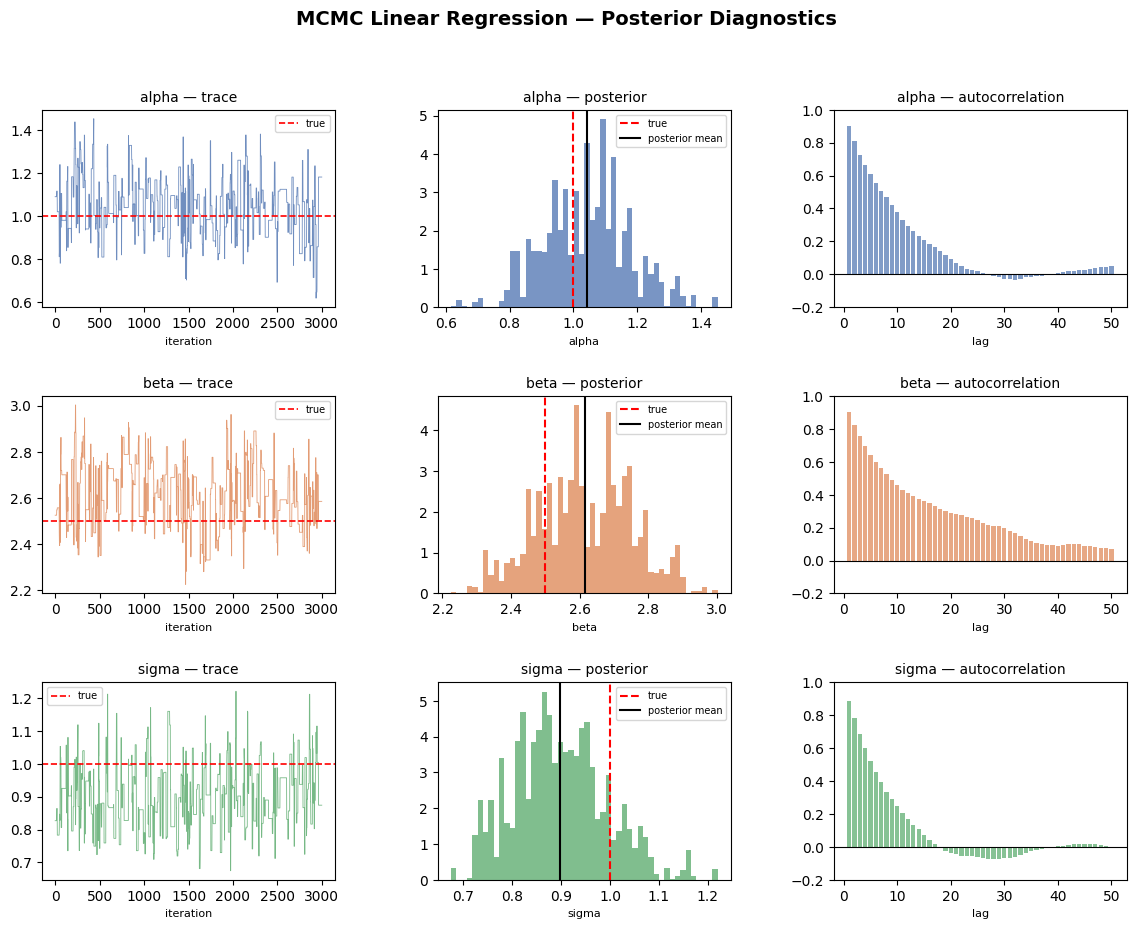

In [14]:
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Distributions ────────────────────────────────────────────────────────────

class Normal:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def log_prob(self, x):
        mean = self.mean(x) if callable(self.mean) else self.mean
        std  = self.std(x)  if callable(self.std)  else self.std
        return sp.norm.logpdf(x, mean, std)

class HalfNormal:
    def __init__(self, scale):
        self.scale = scale

    def log_prob(self, x):
        if x < 0:
            return -np.inf
        return sp.halfnorm.logpdf(x, scale=self.scale)

# ── Core classes ─────────────────────────────────────────────────────────────

class Deterministic:
    def __init__(self, fn):
        self.fn = fn

    def evaluate(self):
        return self.fn()


class Variable:
    def __init__(self, name, dist, parents=None, observed=False, value=None):
        self.name         = name
        self.dist         = dist
        self.parents      = parents if parents is not None else []
        self.observed     = observed
        self.value        = value
        self.deterministic = isinstance(dist, Deterministic)


class Model:
    def __init__(self):
        self.variables = {}

    def add_variable(self, name, dist, parents=None, observed=False):
        if name in self.variables:
            raise ValueError(f"Variable '{name}' already exists.")
        var = Variable(name, dist, parents, observed)
        self.variables[name] = var
        return var

    def add_deterministic(self, name, fn, parents):
        if name in self.variables:
            raise ValueError(f"Variable '{name}' already exists.")
        var = Variable(name, dist=Deterministic(fn), parents=parents, observed=False)
        self.variables[name] = var
        return var

    def topological_sort(self):
        visited = set()
        order   = []

        def dfs(var):
            if var.name in visited:
                return
            visited.add(var.name)
            for parent in var.parents:
                dfs(parent)
            order.append(var)

        for var in self.variables.values():
            dfs(var)
        return order

    def log_prob(self, state):
        logp = 0.0
        for var in self.topological_sort():
            if var.deterministic:
                var.value = var.dist.evaluate()
            else:
                if not var.observed:
                    var.value = state[var.name]
                logp += var.dist.log_prob(var.value)
        return logp


class MCMC:
    def __init__(self, model, initial_state=None):
        self.model = model
        if initial_state is None:
            self.current_state = {
                name: 0.0
                for name, var in model.variables.items()
                if not var.observed and not var.deterministic
            }
        else:
            self.current_state = initial_state
        self.chain    = []
        self.accepted = 0
        self.proposed = 0

    def proposal_step(self):
        return {
            var_name: np.random.normal(self.current_state[var_name], 0.3)
            for var_name, var in self.model.variables.items()
            if not var.observed and not var.deterministic
        }

    def metropolis_step(self):
        proposed_state = self.proposal_step()

        log_p_curr = self.model.log_prob(self.current_state)
        log_p_prop = self.model.log_prob(proposed_state)

        if np.log(np.random.rand()) < (log_p_prop - log_p_curr):
            self.current_state = proposed_state
            self.accepted += 1

        self.proposed += 1
        self.chain.append(self.current_state.copy())

    def sample(self, n_samples=1000, burn_in=1000):
        for _ in range(n_samples + burn_in):
            self.metropolis_step()

        print(f'Total proposed    = {self.proposed}')
        print(f'Total accepted    = {self.accepted}')
        print(f'Acceptance ratio  = {self.accepted/self.proposed:.2f}')

        return self.chain[burn_in:]


# ── Simulate data ─────────────────────────────────────────────────────────────

np.random.seed(42)
N        = 50
X        = np.random.randn(N)
true_alpha = 1.0
true_beta  = 2.5
true_sigma = 1.0
y_obs    = true_alpha + true_beta * X + np.random.randn(N) * true_sigma

print(f"True alpha: {true_alpha}, True beta: {true_beta}, True sigma: {true_sigma}")
print(f"N = {N}\n")

# ── Build model ───────────────────────────────────────────────────────────────

model = Model()

alpha = model.add_variable('alpha', Normal(0, 10))
beta  = model.add_variable('beta',  Normal(0, 10))
sigma = model.add_variable('sigma', HalfNormal(1))

mu = model.add_deterministic('mu', lambda: alpha.value + beta.value * X, parents=[alpha, beta])

# Observed likelihood — score each observation and sum
class NormalLikelihood:
    """Scores a vector of observations against Normal(mu, sigma)."""
    def __init__(self, mu_var, sigma_var, y):
        self.mu_var    = mu_var
        self.sigma_var = sigma_var
        self.y         = y

    def log_prob(self, x):
        return np.sum(sp.norm.logpdf(self.y, self.mu_var.value, self.sigma_var.value))

y = model.add_variable('y', NormalLikelihood(mu, sigma, y_obs),
                        parents=[mu, sigma], observed=True)

# ── Sample ────────────────────────────────────────────────────────────────────

mcmc    = MCMC(model, initial_state={'alpha': 0.0, 'beta': 0.0, 'sigma': 1.0})
samples = mcmc.sample(n_samples=3000, burn_in=1000)

alphas = np.array([s['alpha'] for s in samples])
betas  = np.array([s['beta']  for s in samples])
sigmas = np.array([s['sigma'] for s in samples])

print(f"\nPosterior means:")
print(f"  alpha = {alphas.mean():.3f}  (true: {true_alpha})")
print(f"  beta  = {betas.mean():.3f}  (true: {true_beta})")
print(f"  sigma = {sigmas.mean():.3f}  (true: {true_sigma})")

# ── Plots ─────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 10))
fig.suptitle("MCMC Linear Regression — Posterior Diagnostics", fontsize=14, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

params      = [('alpha', alphas, true_alpha), ('beta', betas, true_beta), ('sigma', sigmas, true_sigma)]
colors      = ['#4C72B0', '#DD8452', '#55A868']

for i, (name, chain, true_val) in enumerate(params):

    # Trace plot
    ax_trace = fig.add_subplot(gs[i, 0])
    ax_trace.plot(chain, lw=0.6, color=colors[i], alpha=0.8)
    ax_trace.axhline(true_val, color='red', lw=1.2, linestyle='--', label='true')
    ax_trace.set_title(f'{name} — trace', fontsize=10)
    ax_trace.set_xlabel('iteration', fontsize=8)
    ax_trace.legend(fontsize=7)

    # Posterior histogram
    ax_hist = fig.add_subplot(gs[i, 1])
    ax_hist.hist(chain, bins=50, color=colors[i], alpha=0.75, density=True)
    ax_hist.axvline(true_val,       color='red',   lw=1.5, linestyle='--', label='true')
    ax_hist.axvline(chain.mean(),   color='black', lw=1.5, linestyle='-',  label='posterior mean')
    ax_hist.set_title(f'{name} — posterior', fontsize=10)
    ax_hist.set_xlabel(name, fontsize=8)
    ax_hist.legend(fontsize=7)

    # Autocorrelation
    ax_acf = fig.add_subplot(gs[i, 2])
    lags    = 50
    acf     = [np.corrcoef(chain[:-k], chain[k:])[0, 1] for k in range(1, lags + 1)]
    ax_acf.bar(range(1, lags + 1), acf, color=colors[i], alpha=0.7, width=0.8)
    ax_acf.axhline(0, color='black', lw=0.8)
    ax_acf.set_title(f'{name} — autocorrelation', fontsize=10)
    ax_acf.set_xlabel('lag', fontsize=8)
    ax_acf.set_ylim(-0.2, 1.0)


True parameters:
  mu      = 2.0
  sigma_u = 1.5
  sigma_e = 0.5
  group effects (u): [ 0.75 -0.21  0.97  2.28 -0.35]

Total proposed   = 7000
Total accepted   = 1214
Acceptance ratio = 0.17

Posterior means vs true values:
  mu:      1.994  (true: 2.0)
  sigma_u: 0.731  (true: 1.5)
  sigma_e: 0.455  (true: 0.5)
  u_0:    0.593  (true: 0.745)
  u_1:    -0.353  (true: -0.207)
  u_2:    0.951  (true: 0.972)
  u_3:    2.308  (true: 2.285)
  u_4:    -0.431  (true: -0.351)


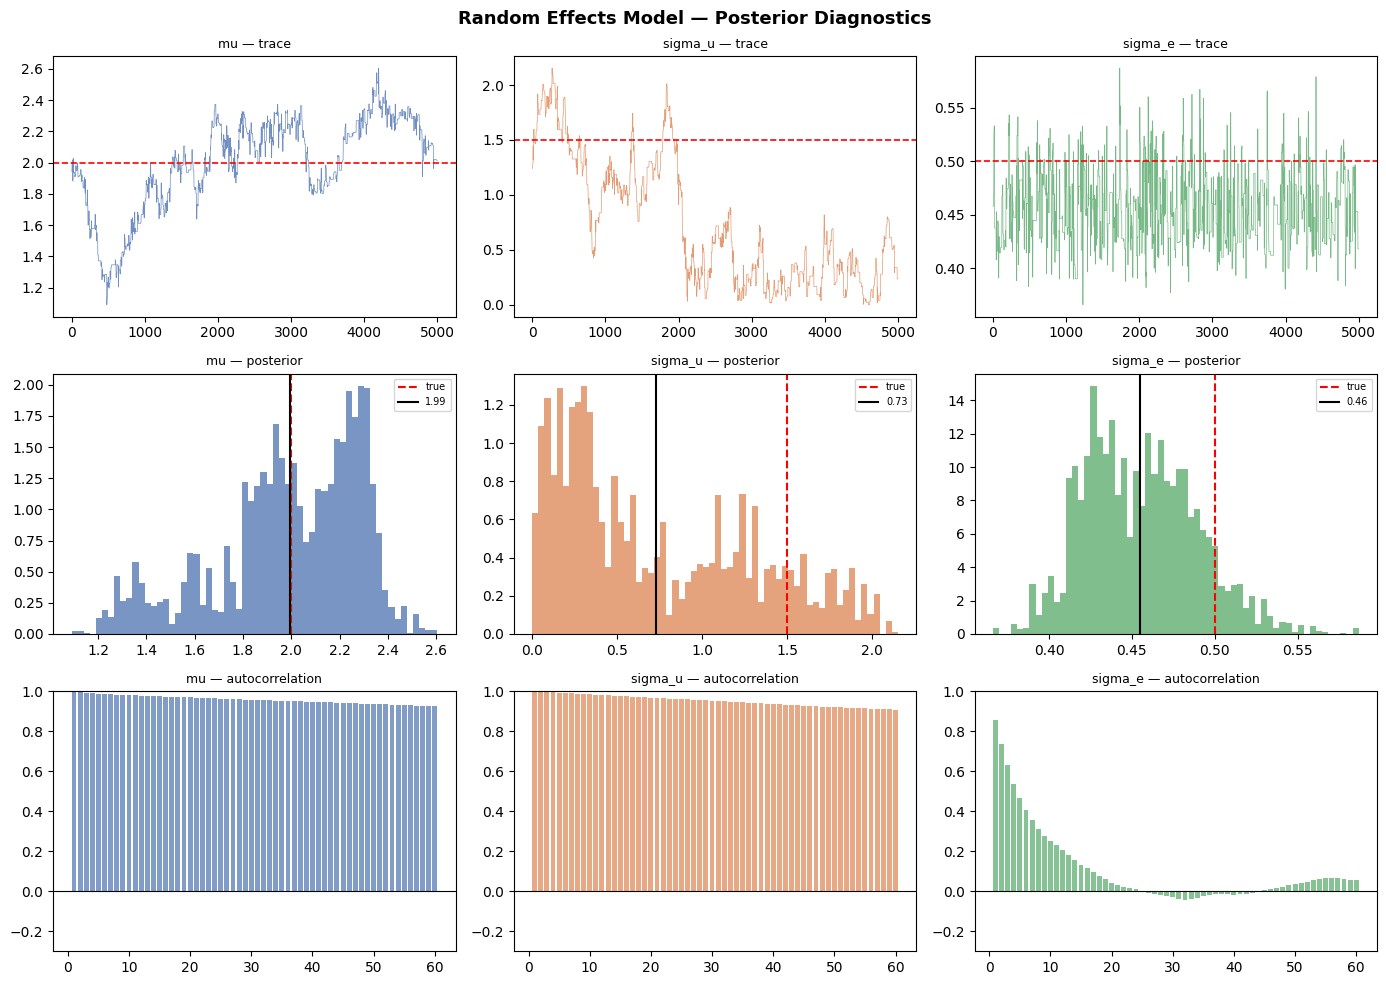

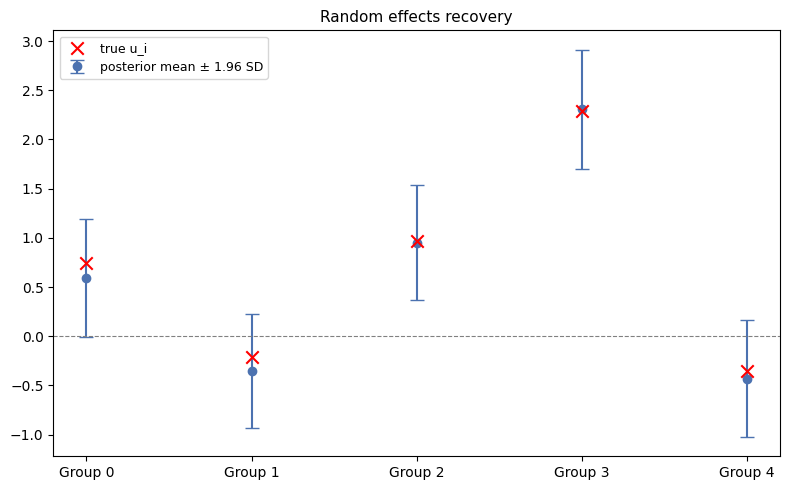

In [16]:
 
class Normal:
    def __init__(self, mean, std):
        self.mean = mean
        self.std  = std
 
    def log_prob(self, x):
        mean = self.mean(x) if callable(self.mean) else self.mean
        std  = self.std(x)  if callable(self.std)  else self.std
        return sp.norm.logpdf(x, mean, std)
 
class HalfNormal:
    def __init__(self, scale):
        self.scale = scale
 
    def log_prob(self, x):
        if x < 0:
            return -np.inf
        return sp.halfnorm.logpdf(x, scale=self.scale)
 
class Poisson:
    def __init__(self, lam_var):
        self.lam_var = lam_var
 
    def log_prob(self, x):
        lam = self.lam_var.value
        if np.any(lam <= 0):
            return -np.inf
        return np.sum(sp.poisson.logpmf(x, lam))
 
class Bernoulli:
    def __init__(self, p):
        self.p = p
 
    def log_prob(self, x):
        p = self.p(x) if callable(self.p) else self.p
        return sp.bernoulli.logpmf(x, p)
 
class Exponential:
    def __init__(self, rate):
        self.rate = rate
 
    def log_prob(self, x):
        return sp.expon.logpdf(x, scale=1/self.rate)
 
class Beta:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta  = beta
 
    def log_prob(self, x):
        return sp.beta.logpdf(x, self.alpha, self.beta)
 
class Uniform:
    def __init__(self, low, high):
        self.low  = low
        self.high = high
 
    def log_prob(self, x):
        return sp.uniform.logpdf(x, self.low, self.high - self.low)
 
# ── Core classes ──────────────────────────────────────────────────────────────
 
class Deterministic:
    def __init__(self, fn):
        self.fn = fn
 
    def evaluate(self):
        return self.fn()
 
 
class Variable:
    def __init__(self, name, dist, parents=None, observed=False, value=None):
        self.name          = name
        self.dist          = dist
        self.parents       = parents if parents is not None else []
        self.observed      = observed
        self.value         = value
        self.deterministic = isinstance(dist, Deterministic)
 
 
class Model:
    def __init__(self):
        self.variables = {}
 
    def add_variable(self, name, dist, parents=None, observed=False, observed_data=None):
        if name in self.variables:
            raise ValueError(f"Variable '{name}' already exists.")
        var = Variable(name, dist, parents, observed, value=observed_data)
        self.variables[name] = var
        return var
 
    def add_deterministic(self, name, fn, parents):
        if name in self.variables:
            raise ValueError(f"Variable '{name}' already exists.")
        var = Variable(name, dist=Deterministic(fn), parents=parents, observed=False)
        self.variables[name] = var
        return var
 
    def topological_sort(self):
        visited = set()
        order   = []
 
        def dfs(var):
            if var.name in visited:
                return
            visited.add(var.name)
            for parent in var.parents:
                dfs(parent)
            order.append(var)
 
        for var in self.variables.values():
            dfs(var)
        return order
 
    def log_prob(self, state):
        logp = 0.0
        for var in self.topological_sort():
            if var.deterministic:
                var.value = var.dist.evaluate()
            else:
                if not var.observed:
                    var.value = state[var.name]
                logp += var.dist.log_prob(var.value)
        return logp
 
 
class MCMC:
    def __init__(self, model, initial_state=None, proposal_std=0.1):
        self.model        = model
        self.proposal_std = proposal_std
        if initial_state is None:
            self.current_state = {
                name: 0.0
                for name, var in model.variables.items()
                if not var.observed and not var.deterministic
            }
        else:
            self.current_state = initial_state
        self.chain    = []
        self.accepted = 0
        self.proposed = 0
 
    def proposal_step(self):
        return {
            var_name: np.random.normal(self.current_state[var_name], self.proposal_std)
            for var_name, var in self.model.variables.items()
            if not var.observed and not var.deterministic
        }
 
    def metropolis_step(self):
        proposed_state = self.proposal_step()
        log_p_curr     = self.model.log_prob(self.current_state)
        log_p_prop     = self.model.log_prob(proposed_state)
 
        if np.log(np.random.rand()) < (log_p_prop - log_p_curr):
            self.current_state = proposed_state
            self.accepted += 1
 
        self.proposed += 1
        self.chain.append(self.current_state.copy())
 
    def sample(self, n_samples=1000, burn_in=1000):
        for _ in range(n_samples + burn_in):
            self.metropolis_step()
 
        print(f'Total proposed   = {self.proposed}')
        print(f'Total accepted   = {self.accepted}')
        print(f'Acceptance ratio = {self.accepted/self.proposed:.2f}')
        return self.chain[burn_in:]
 
 
# ── Random effects model ──────────────────────────────────────────────────────
# y_ij = mu + u_i + e_ij
# mu        ~ Normal(0, 5)        global mean
# sigma_u   ~ HalfNormal(1)       group-level SD
# sigma_e   ~ HalfNormal(1)       observation-level SD
# u_i       ~ Normal(0, sigma_u)  group random effects
# y_ij      ~ Normal(mu + u_i, sigma_e)
 
np.random.seed(42)
n_groups  = 5
n_per_grp = 20
N         = n_groups * n_per_grp
 
true_mu      = 2.0
true_sigma_u = 1.5   # between-group SD
true_sigma_e = 0.5   # within-group SD
 
group_ids    = np.repeat(np.arange(n_groups), n_per_grp)
true_u       = np.random.normal(0, true_sigma_u, n_groups)
y_obs        = (true_mu
                + true_u[group_ids]
                + np.random.normal(0, true_sigma_e, N))
 
print("True parameters:")
print(f"  mu      = {true_mu}")
print(f"  sigma_u = {true_sigma_u}")
print(f"  sigma_e = {true_sigma_e}")
print(f"  group effects (u): {np.round(true_u, 2)}\n")
 
# ── Build model ───────────────────────────────────────────────────────────────
 
model   = Model()
 
mu      = model.add_variable('mu',      Normal(0, 5))
sigma_u = model.add_variable('sigma_u', HalfNormal(1))
sigma_e = model.add_variable('sigma_e', HalfNormal(1))
 
# One random effect per group
u = [model.add_variable(f'u_{i}', Normal(0, 1), parents=[sigma_u])
     for i in range(n_groups)]
 
# Deterministic mean for each observation
mu_obs = model.add_deterministic(
    'mu_obs',
    lambda: mu.value + np.array([u[g].value for g in group_ids]),
    parents=[mu, *u]
)
 
# Observed likelihood
class NormalVecLikelihood:
    def __init__(self, mu_var, sigma_var, y):
        self.mu_var    = mu_var
        self.sigma_var = sigma_var
        self.y         = y
 
    def log_prob(self, x):
        return np.sum(sp.norm.logpdf(self.y, self.mu_var.value, self.sigma_var.value))
 
y = model.add_variable(
    'y',
    NormalVecLikelihood(mu_obs, sigma_e, y_obs),
    parents=[mu_obs, sigma_e],
    observed=True,
    observed_data=y_obs
)
 
# ── Sample ────────────────────────────────────────────────────────────────────
 
initial_state = {'mu': 0.0, 'sigma_u': 1.0, 'sigma_e': 1.0,
                 **{f'u_{i}': 0.0 for i in range(n_groups)}}
 
mcmc    = MCMC(model, initial_state=initial_state, proposal_std=0.08)
samples = mcmc.sample(n_samples=5000, burn_in=2000)
 
# Extract chains
mu_chain      = np.array([s['mu']      for s in samples])
sigma_u_chain = np.array([s['sigma_u'] for s in samples])
sigma_e_chain = np.array([s['sigma_e'] for s in samples])
u_chains      = [np.array([s[f'u_{i}'] for s in samples]) for i in range(n_groups)]
 
print("\nPosterior means vs true values:")
print(f"  mu:      {mu_chain.mean():.3f}  (true: {true_mu})")
print(f"  sigma_u: {sigma_u_chain.mean():.3f}  (true: {true_sigma_u})")
print(f"  sigma_e: {sigma_e_chain.mean():.3f}  (true: {true_sigma_e})")
for i in range(n_groups):
    print(f"  u_{i}:    {u_chains[i].mean():.3f}  (true: {true_u[i]:.3f})")
 
# ── Plots ─────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Random Effects Model — Posterior Diagnostics", fontsize=13, fontweight='bold')
 
global_params = [
    ('mu',      mu_chain,      true_mu),
    ('sigma_u', sigma_u_chain, true_sigma_u),
    ('sigma_e', sigma_e_chain, true_sigma_e),
]
colors = ['#4C72B0', '#DD8452', '#55A868']
 
for col, (name, chain, true_val) in enumerate(global_params):
    color = colors[col]
 
    axes[0, col].plot(chain, lw=0.5, color=color, alpha=0.8)
    axes[0, col].axhline(true_val, color='red', lw=1.2, linestyle='--')
    axes[0, col].set_title(f'{name} — trace', fontsize=9)
 
    axes[1, col].hist(chain, bins=60, color=color, alpha=0.75, density=True)
    axes[1, col].axvline(true_val,     color='red',   lw=1.5, linestyle='--', label='true')
    axes[1, col].axvline(chain.mean(), color='black', lw=1.5, linestyle='-',  label=f'{chain.mean():.2f}')
    axes[1, col].set_title(f'{name} — posterior', fontsize=9)
    axes[1, col].legend(fontsize=7)
 
    lags = 60
    acf  = [np.corrcoef(chain[:-k], chain[k:])[0, 1] for k in range(1, lags + 1)]
    axes[2, col].bar(range(1, lags + 1), acf, color=color, alpha=0.7, width=0.8)
    axes[2, col].axhline(0, color='black', lw=0.8)
    axes[2, col].set_title(f'{name} — autocorrelation', fontsize=9)
    axes[2, col].set_ylim(-0.3, 1.0)
 
plt.tight_layout()
 
# Random effects recovery plot
fig2, ax = plt.subplots(figsize=(8, 5))
post_means = [u_chains[i].mean() for i in range(n_groups)]
post_stds  = [u_chains[i].std()  for i in range(n_groups)]
x          = np.arange(n_groups)
 
ax.errorbar(x, post_means, yerr=1.96*np.array(post_stds),
            fmt='o', color='#4C72B0', capsize=5, label='posterior mean ± 1.96 SD')
ax.scatter(x, true_u, color='red', zorder=5, label='true u_i', marker='x', s=80)
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([f'Group {i}' for i in range(n_groups)])
ax.set_title('Random effects recovery', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()